## Trabajo Practico N° 3

Integrantes:
- Gonzalo Martin Rodriguez
- Matias Bovio
- Carmen Rodriguez

In [1]:
%matplotlib inline

import os
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

##### *Objetivo*

Encontrar el logotipo de la gaseosa dentro de las imágenes de la carpeta `images` a partir del template `template/pattern.png`. Se pide una detección por imagen (ítem 1), múltiples detecciones en `coca_multi.png` (ítem 2) y generalizar ese algoritmo a todas las imágenes (ítem 3).

Lo resolvemos con template matching, como en la clase 4. Como el logo aparece con distintos colores y tamaños, trabajamos sobre los bordes (Canny) y probamos varias escalas. Usamos los mismos parámetros para todas las imágenes.

In [2]:
carpeta_imagenes = 'images'
nombres = sorted(os.listdir(carpeta_imagenes))
print(nombres)

['COCA-COLA-LOGO.jpg', 'coca_logo_1.png', 'coca_logo_2.png', 'coca_multi.png', 'coca_retro_1.png', 'coca_retro_2.png', 'logo_1.png']


##### *Parte 1: Preparación del template*

El template es rojo sobre fondo blanco, pero en las imágenes el logo aparece blanco sobre rojo o negro sobre papel. Lo que se mantiene es la forma, así que en lugar de comparar intensidades comparamos bordes.

Para no elegir a mano los umbrales de Canny en cada imagen, usamos como umbral alto el valor que devuelve Otsu (clase 2) y como umbral bajo la mitad. Después suavizamos la imagen de bordes con un filtro gaussiano: los bordes de Canny tienen un píxel de ancho y, si el logo de la imagen no coincide exactamente con el template, casi no se solapan. Al ensancharlos la comparación tolera esas diferencias.

In [3]:
def obtener_bordes(gris):
    # Suavizamos un poco antes de buscar bordes
    suavizada = cv.GaussianBlur(gris, (3, 3), 0)
    # Umbral alto de Canny = umbral de Otsu, umbral bajo = la mitad
    umbral_otsu, _ = cv.threshold(suavizada, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    bordes = cv.Canny(suavizada, umbral_otsu / 2, umbral_otsu)
    # Ensanchamos los bordes con un filtro gaussiano
    bordes = cv.GaussianBlur(bordes, (0, 0), 1.5)
    return bordes

Leemos el template, recortamos el margen blanco que tiene alrededor y lo llevamos a un ancho fijo de 128 píxeles.

Tamaño del template (alto, ancho): (40, 128)


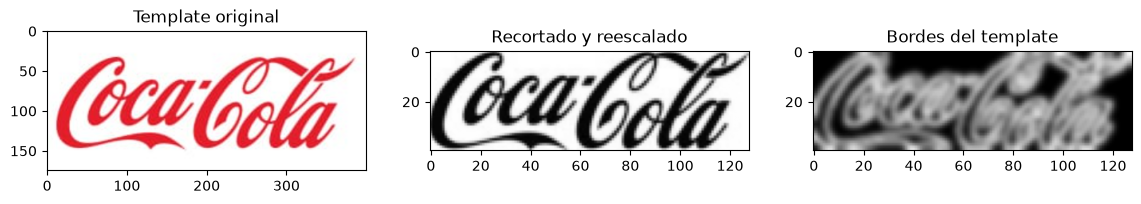

In [4]:
template_color = cv.imread('template/pattern.png')
template_gris = cv.cvtColor(template_color, cv.COLOR_BGR2GRAY)

# Buscamos donde hay bordes para recortar el margen blanco
bordes_template = cv.Canny(template_gris, 100, 200)
filas, columnas = np.where(bordes_template > 0)
template_recortado = template_gris[filas.min():filas.max() + 1, columnas.min():columnas.max() + 1]

# Lo llevamos a un ancho fijo manteniendo la relacion de aspecto
ancho_t = 128
alto_t = int(ancho_t * template_recortado.shape[0] / template_recortado.shape[1])
template_chico = cv.resize(template_recortado, (ancho_t, alto_t), interpolation=cv.INTER_AREA)

# Template final: imagen de bordes
template = obtener_bordes(template_chico)
print('Tamaño del template (alto, ancho):', template.shape)

plt.figure(figsize=(14, 3))
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(template_color, cv.COLOR_BGR2RGB))
plt.title('Template original')
plt.subplot(1, 3, 2)
plt.imshow(template_chico, cmap='gray')
plt.title('Recortado y reescalado')
plt.subplot(1, 3, 3)
plt.imshow(template, cmap='gray')
plt.title('Bordes del template')
plt.show()

##### *Parte 2: Template matching sobre una imagen de prueba*

Antes de armar el algoritmo completo lo probamos paso a paso sobre una imagen. Primero vemos cómo queda la imagen de bordes.

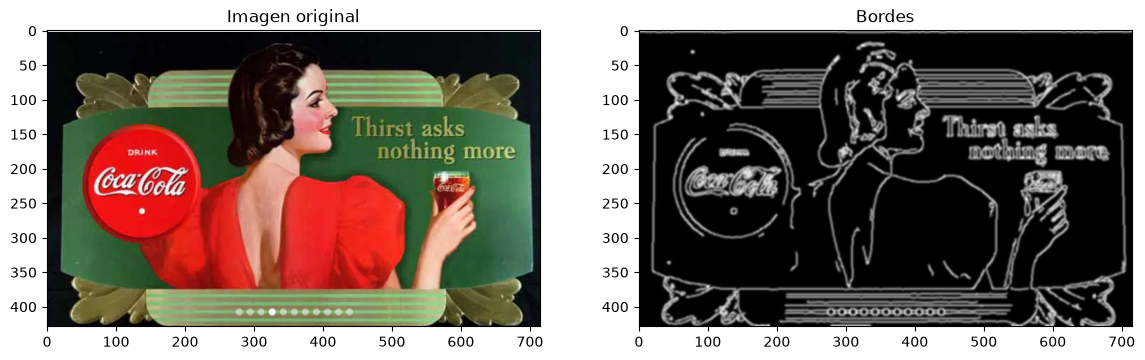

In [5]:
imagen_prueba = cv.imread('images/coca_retro_2.png')
gris_prueba = cv.cvtColor(imagen_prueba, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(imagen_prueba, cv.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.subplot(1, 2, 2)
plt.imshow(obtener_bordes(gris_prueba), cmap='gray')
plt.title('Bordes')
plt.show()

El template matching solo es invariante a desplazamientos, y no sabemos de qué tamaño está el logo en cada imagen. Por eso armamos un vector de escalas y en cada una reescalamos la imagen con `cv.resize`.

Reescalamos la imagen y no el template: así el template tiene siempre la misma cantidad de píxeles y los valores de la métrica se pueden comparar entre escalas. Las escalas no están fijas por imagen: probamos que el logo ocupe desde el 4% hasta el 100% del ancho de la imagen, sea cual sea su tamaño.

Usamos `TM_CCOEFF_NORMED`, que es una métrica normalizada, para poder poner un umbral. En cada escala guardamos el valor máximo del mapa de resultado.

In [6]:
fracciones = np.linspace(0.04, 1.0, 60)
ancho_imagen = gris_prueba.shape[1]

maximos = []
mapas = []
escalas = []
for fraccion in fracciones:
    # Escala para que un logo que ocupa esa fraccion del ancho quede del tamaño del template
    escala = ancho_t / (fraccion * ancho_imagen)
    reescalada = cv.resize(gris_prueba, None, fx=escala, fy=escala)
    # Si el template no entra en la imagen reescalada salteamos esa escala
    if reescalada.shape[0] < alto_t or reescalada.shape[1] < ancho_t:
        continue
    res = cv.matchTemplate(obtener_bordes(reescalada), template, cv.TM_CCOEFF_NORMED)
    maximos.append(res.max())
    mapas.append(res)
    escalas.append(escala)

maximos = np.array(maximos)
indice_mejor = np.argmax(maximos)
print('Mejor valor de la metrica:', round(float(maximos[indice_mejor]), 2))
print('Ancho del logo en esa escala:', int(ancho_t / escalas[indice_mejor]), 'pixeles')

Mejor valor de la metrica: 0.72
Ancho del logo en esa escala: 144 pixeles


Graficamos el máximo de la métrica en cada escala. Hay un pico claro en la escala donde el tamaño del logo coincide con el del template, y el resto de las escalas queda en un nivel bastante parejo.

Ese nivel parejo lo usamos para definir el umbral de detección sin fijar un número a mano: tomamos la mediana de los máximos como "piso" (lo que vale un máximo cuando el logo no está) y ponemos el umbral a mitad de camino entre el piso y el mejor valor.

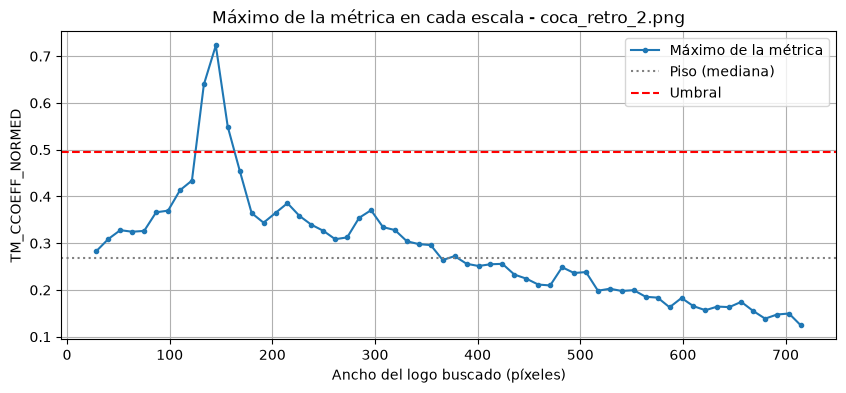

In [7]:
piso = np.median(maximos)
umbral = piso + 0.5 * (maximos.max() - piso)

anchos_logo = ancho_t / np.array(escalas)

plt.figure(figsize=(10, 4))
plt.plot(anchos_logo, maximos, marker='.', label='Máximo de la métrica')
plt.axhline(piso, color='gray', linestyle=':', label='Piso (mediana)')
plt.axhline(umbral, color='red', linestyle='--', label='Umbral')
plt.xlabel('Ancho del logo buscado (píxeles)')
plt.ylabel('TM_CCOEFF_NORMED')
plt.title('Máximo de la métrica en cada escala - coca_retro_2.png')
plt.legend()
plt.grid()
plt.show()

Mostramos el mapa de resultado en la mejor escala y la detección. El máximo del mapa corresponde a la esquina superior izquierda del template; para volver a las coordenadas de la imagen original dividimos por la escala.

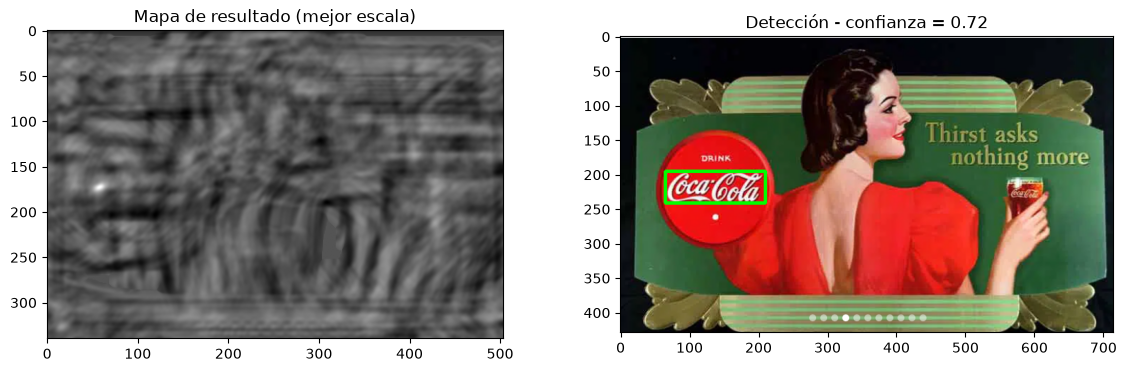

In [8]:
res = mapas[indice_mejor]
escala = escalas[indice_mejor]
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

# Esquinas del bounding box en la imagen original
x1 = int(max_loc[0] / escala)
y1 = int(max_loc[1] / escala)
x2 = int((max_loc[0] + ancho_t) / escala)
y2 = int((max_loc[1] + alto_t) / escala)

salida = imagen_prueba.copy()
cv.rectangle(salida, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.imshow(res, cmap='gray')
plt.title('Mapa de resultado (mejor escala)')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(salida, cv.COLOR_BGR2RGB))
plt.title('Detección - confianza = ' + str(round(float(max_val), 2)))
plt.show()

##### *Parte 3: Función de búsqueda*

Juntamos los pasos anteriores en una función para poder usarla sobre todas las imágenes. Recorre las escalas, calcula el umbral y devuelve todas las posiciones que lo superan, cada una con su bounding box y su nivel de confianza (el valor de la métrica).

In [9]:
def buscar_candidatos(gris, template):
    alto_t, ancho_t = template.shape
    ancho_imagen = gris.shape[1]

    # Template matching en cada escala
    mapas = []
    escalas = []
    maximos = []
    for fraccion in np.linspace(0.04, 1.0, 60):
        escala = ancho_t / (fraccion * ancho_imagen)
        reescalada = cv.resize(gris, None, fx=escala, fy=escala)
        if reescalada.shape[0] < alto_t or reescalada.shape[1] < ancho_t:
            continue
        res = cv.matchTemplate(obtener_bordes(reescalada), template, cv.TM_CCOEFF_NORMED)
        mapas.append(res)
        escalas.append(escala)
        maximos.append(res.max())

    # Umbral: a mitad de camino entre el piso (mediana de los maximos) y el mejor valor
    piso = np.median(maximos)
    umbral = piso + 0.5 * (max(maximos) - piso)

    # Nos quedamos con todas las posiciones que superan el umbral
    cajas = []
    confianzas = []
    for i in range(len(mapas)):
        res = mapas[i]
        escala = escalas[i]
        loc = np.where(res >= umbral)
        for pt in zip(*loc[::-1]):  # el [::-1] invierte el orden: necesitamos (x, y) y no (y, x)
            x1 = int(pt[0] / escala)
            y1 = int(pt[1] / escala)
            x2 = int((pt[0] + ancho_t) / escala)
            y2 = int((pt[1] + alto_t) / escala)
            cajas.append((x1, y1, x2, y2))
            confianzas.append(float(res[pt[1], pt[0]]))

    return cajas, confianzas, umbral

##### *Ítem 1: una detección del logo en cada imagen*

Para cada imagen nos quedamos con el candidato de mayor confianza, es decir, el máximo de la métrica entre todas las escalas.

COCA-COLA-LOGO.jpg - confianza: 0.67
coca_logo_1.png - confianza: 0.75
coca_logo_2.png - confianza: 0.63
coca_multi.png - confianza: 0.63
coca_retro_1.png - confianza: 0.75
coca_retro_2.png - confianza: 0.72
logo_1.png - confianza: 0.59


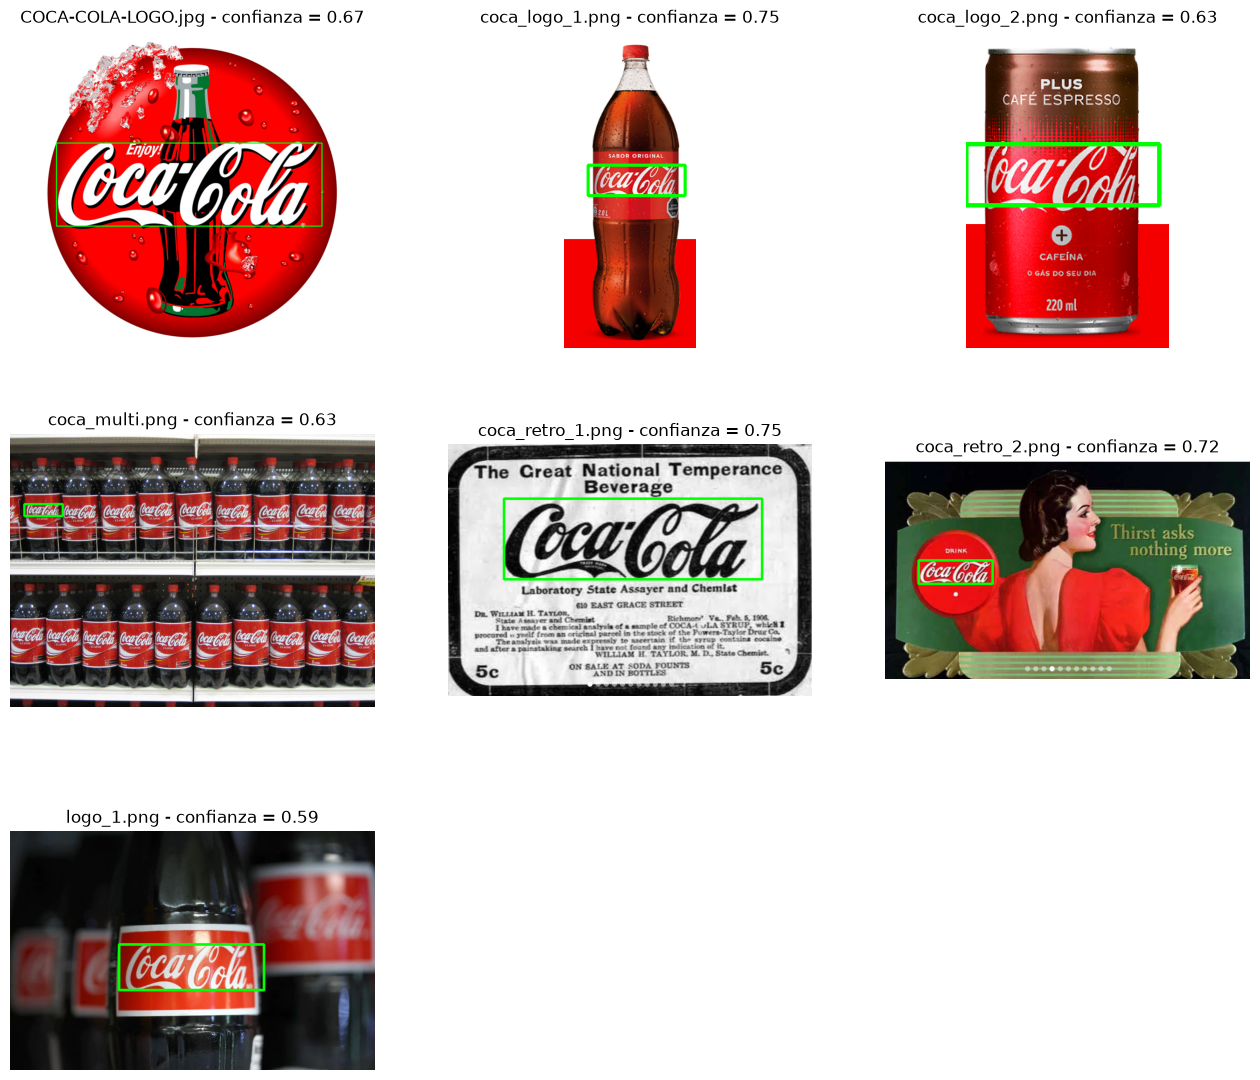

In [10]:
plt.figure(figsize=(16, 14))
for i in range(len(nombres)):
    imagen = cv.imread(carpeta_imagenes + '/' + nombres[i])
    gris = cv.cvtColor(imagen, cv.COLOR_BGR2GRAY)

    cajas, confianzas, umbral = buscar_candidatos(gris, template)

    # Candidato de mayor confianza
    mejor = np.argmax(confianzas)
    x1, y1, x2, y2 = cajas[mejor]
    cv.rectangle(imagen, (x1, y1), (x2, y2), (0, 255, 0), 3)
    print(nombres[i], '- confianza:', round(confianzas[mejor], 2))

    plt.subplot(3, 3, i + 1)
    plt.imshow(cv.cvtColor(imagen, cv.COLOR_BGR2RGB))
    plt.title(nombres[i] + ' - confianza = ' + str(round(confianzas[mejor], 2)))
    plt.axis('off')
plt.show()

##### *Ítem 2: múltiples detecciones en coca_multi.png*

Ahora no alcanza con el máximo: tomamos todos los candidatos que superan el umbral. Primero los dibujamos tal cual salen.

Umbral utilizado: 0.44
Cantidad de candidatos por encima del umbral: 923


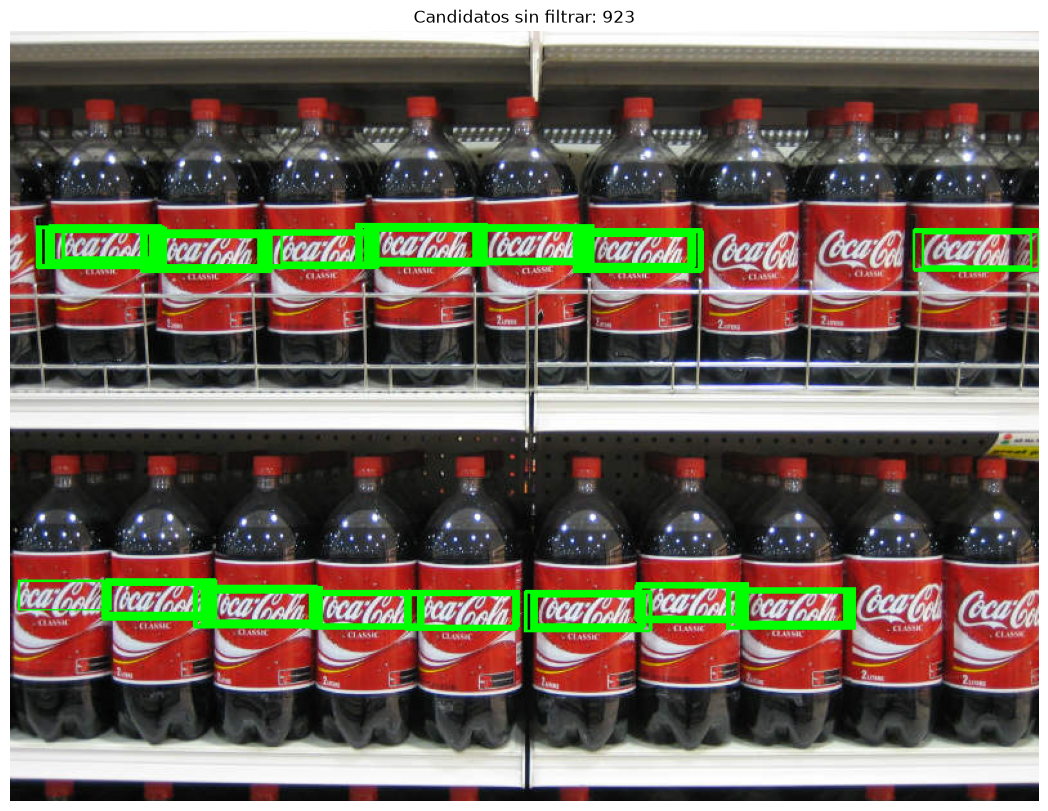

In [11]:
imagen_multi = cv.imread('images/coca_multi.png')
gris_multi = cv.cvtColor(imagen_multi, cv.COLOR_BGR2GRAY)

cajas, confianzas, umbral = buscar_candidatos(gris_multi, template)
print('Umbral utilizado:', round(float(umbral), 2))
print('Cantidad de candidatos por encima del umbral:', len(cajas))

salida = imagen_multi.copy()
for (x1, y1, x2, y2) in cajas:
    cv.rectangle(salida, (x1, y1), (x2, y2), (0, 255, 0), 1)

plt.figure(figsize=(14, 10))
plt.imshow(cv.cvtColor(salida, cv.COLOR_BGR2RGB))
plt.title('Candidatos sin filtrar: ' + str(len(cajas)))
plt.axis('off')
plt.show()

Pasa lo que vimos en clase: cada logo aparece detectado muchas veces, porque cuando el template está corrido unos pocos píxeles (o en una escala vecina) la métrica sigue por encima del umbral. Los rectángulos se apilan y se ven como un bounding box "gordo".

Para quedarnos con una sola caja por logo implementamos supresión de no-máximos usando Intersection over Union (IoU): el área de la intersección de dos cajas dividida por el área de la unión. Vale 0 si no se tocan y 1 si coinciden.

In [12]:
def calcular_iou(caja_a, caja_b):
    # Rectangulo de interseccion
    x1 = max(caja_a[0], caja_b[0])
    y1 = max(caja_a[1], caja_b[1])
    x2 = min(caja_a[2], caja_b[2])
    y2 = min(caja_a[3], caja_b[3])
    interseccion = max(0, x2 - x1) * max(0, y2 - y1)

    area_a = (caja_a[2] - caja_a[0]) * (caja_a[3] - caja_a[1])
    area_b = (caja_b[2] - caja_b[0]) * (caja_b[3] - caja_b[1])
    union = area_a + area_b - interseccion
    return interseccion / union

In [13]:
def suprimir_no_maximos(cajas, confianzas, umbral_iou=0.3):
    # Ordenamos los candidatos de mayor a menor confianza
    orden = np.argsort(confianzas)[::-1]

    elegidas = []
    for i in orden:
        # Nos fijamos si se solapa con alguna caja que ya elegimos
        se_solapa = False
        for j in elegidas:
            if calcular_iou(cajas[i], cajas[j]) >= umbral_iou:
                se_solapa = True
                break
        # Si no se solapa con ninguna, es un logo nuevo
        if not se_solapa:
            elegidas.append(i)
    return elegidas

Detecciones luego de la supresion de no-maximos: 15


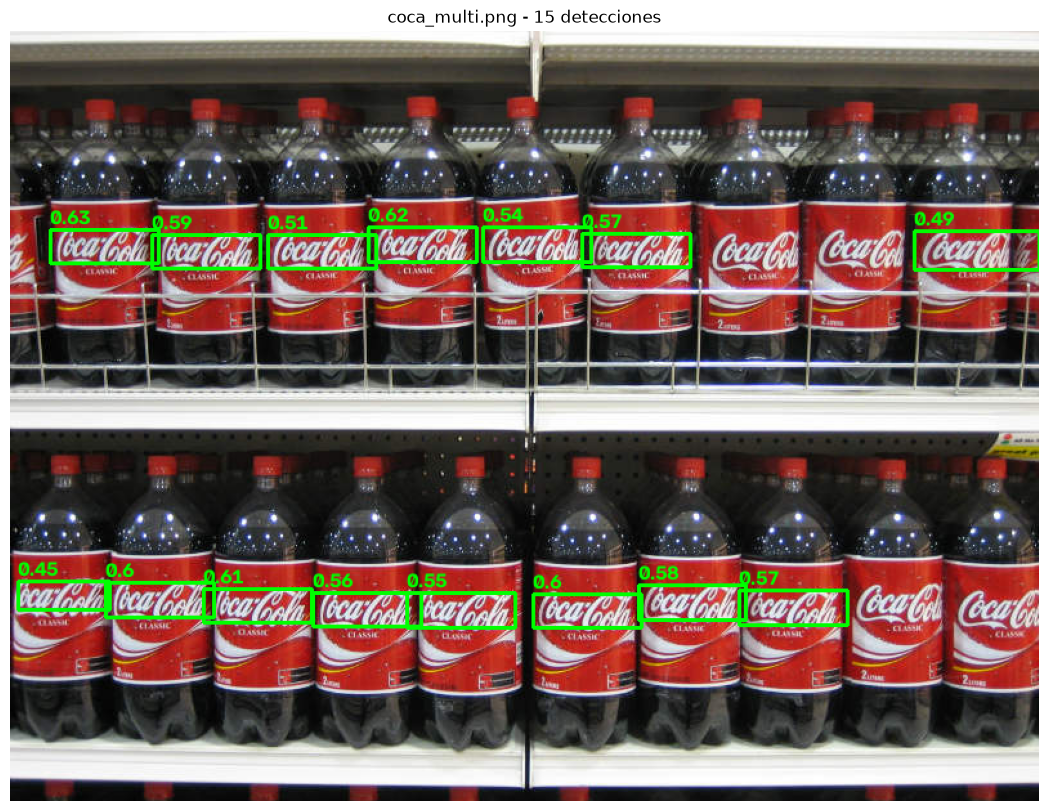

In [14]:
elegidas = suprimir_no_maximos(cajas, confianzas)
print('Detecciones luego de la supresion de no-maximos:', len(elegidas))

salida = imagen_multi.copy()
for i in elegidas:
    x1, y1, x2, y2 = cajas[i]
    cv.rectangle(salida, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv.putText(salida, str(round(confianzas[i], 2)), (x1, y1 - 4), cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.figure(figsize=(14, 10))
plt.imshow(cv.cvtColor(salida, cv.COLOR_BGR2RGB))
plt.title('coca_multi.png - ' + str(len(elegidas)) + ' detecciones')
plt.axis('off')
plt.show()

##### *Ítem 3: el mismo algoritmo para todas las imágenes*

Corremos exactamente lo mismo del ítem 2 (candidatos por encima del umbral + supresión de no-máximos) sobre todas las imágenes, sin cambiar ningún parámetro. El algoritmo no sabe cuántos logos hay en cada una.

COCA-COLA-LOGO.jpg - detecciones: 1 - umbral: 0.51
   confianza: 0.67
coca_logo_1.png - detecciones: 1 - umbral: 0.57
   confianza: 0.75
coca_logo_2.png - detecciones: 1 - umbral: 0.49
   confianza: 0.63
coca_multi.png - detecciones: 15 - umbral: 0.44
   confianza: 0.63
   confianza: 0.62
   confianza: 0.61
   confianza: 0.6
   confianza: 0.6
   confianza: 0.59
   confianza: 0.58
   confianza: 0.57
   confianza: 0.57
   confianza: 0.56
   confianza: 0.55
   confianza: 0.54
   confianza: 0.51
   confianza: 0.49
   confianza: 0.45
coca_retro_1.png - detecciones: 1 - umbral: 0.56
   confianza: 0.75
coca_retro_2.png - detecciones: 1 - umbral: 0.5
   confianza: 0.72
logo_1.png - detecciones: 1 - umbral: 0.46
   confianza: 0.59


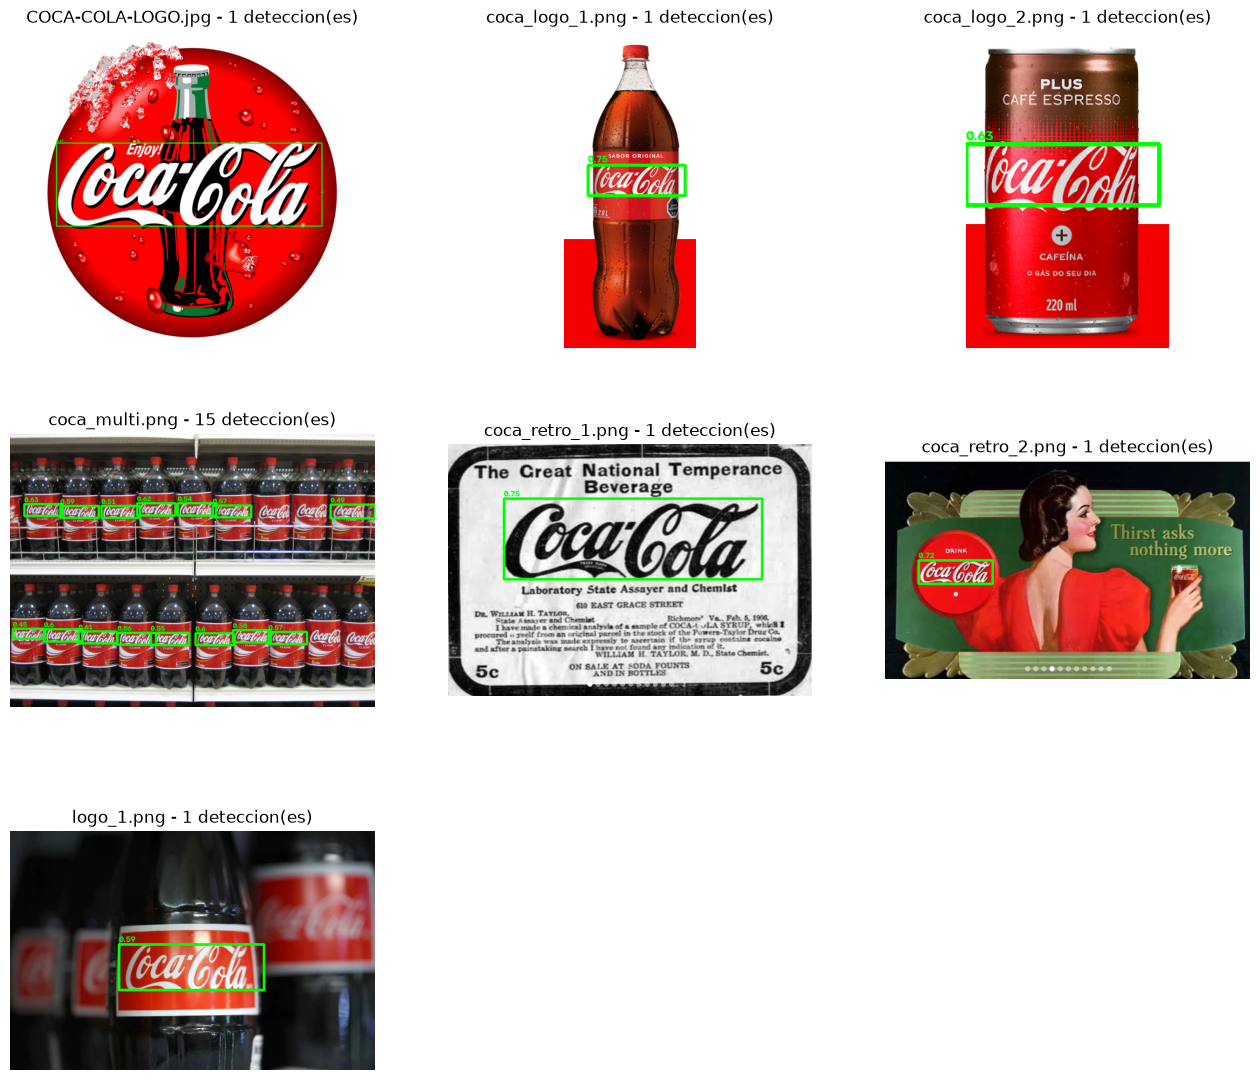

In [15]:
plt.figure(figsize=(16, 14))
for i in range(len(nombres)):
    imagen = cv.imread(carpeta_imagenes + '/' + nombres[i])
    gris = cv.cvtColor(imagen, cv.COLOR_BGR2GRAY)

    cajas, confianzas, umbral = buscar_candidatos(gris, template)
    elegidas = suprimir_no_maximos(cajas, confianzas)
    print(nombres[i], '- detecciones:', len(elegidas), '- umbral:', round(float(umbral), 2))

    for j in elegidas:
        print('   confianza:', round(confianzas[j], 2))
        x1, y1, x2, y2 = cajas[j]
        cv.rectangle(imagen, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv.putText(imagen, str(round(confianzas[j], 2)), (x1, y1 - 4), cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.subplot(3, 3, i + 1)
    plt.imshow(cv.cvtColor(imagen, cv.COLOR_BGR2RGB))
    plt.title(nombres[i] + ' - ' + str(len(elegidas)) + ' deteccion(es)')
    plt.axis('off')
plt.show()

#### **Conclusión:**

- **Se utilizó borde:** se tuvo en cuenta que el template es rojo sobre blanco y que en las imágenes el logo está en diferentes combinaciones de colores. Con bordes se mantiene la forma.
- **Se suavizaron bordes:** con un solo píxel de borde la medición iba a ser muy sensible a diferencias chicas de forma o de escala, entonces se ensancharon.
- **Escalamos las imágenes y no el template:** si se achica el template se corre el riesgo de que queden pocos píxeles y la correlación normalizada dé valores altos por casualidad. Con el template de tamaño fijo, los valores se pueden comparar entre escalas.
- **Cálculo de umbral:** para que no sea fijo se calculó en cada imagen a partir de la mediana de los máximos y del mejor valor.
- **Confianza como métrica:** es el valor de la métrica, sabemos que no es una probabilidad.

- **Ítem 1:** se obtuvo una detección correcta en las 7 imágenes, sin falsos positivos. Las confianzas van de 0,59 a 0,75.
- **Ítem 2:** en `coca_multi.png` salieron 923 candidatos por encima del umbral y, después de la supresión de no-máximos, quedaron 15 detecciones, sin falsos positivos ni cajas repetidas. Los logos que no se detectan corresponden a botellas que están giradas: el final de la palabra queda sobre el costado curvo de la botella y se ve comprimido o tapado, cambia la proporción del logo respecto del template y el valor queda por debajo del umbral.
- **Ítem 3:** el mismo algoritmo que el ítem 2, sin tocar nada, da una sola detección en las imágenes con un logo y 15 en la múltiple.